In [1]:
# Cell 1: Imports and Random Seed Setup

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min

# Set global random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Cell 2 (revised): Load dataset and initial exploration without ace_tools

file_path = r"C:\Users\COMPUMARTS\Downloads\Mall_Customers.csv"
df = pd.read_csv(file_path)

# Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

# DataFrame structure and types
print("\nDataframe Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive statistics for numeric features:")
display(df.describe())


First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive statistics for numeric features:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


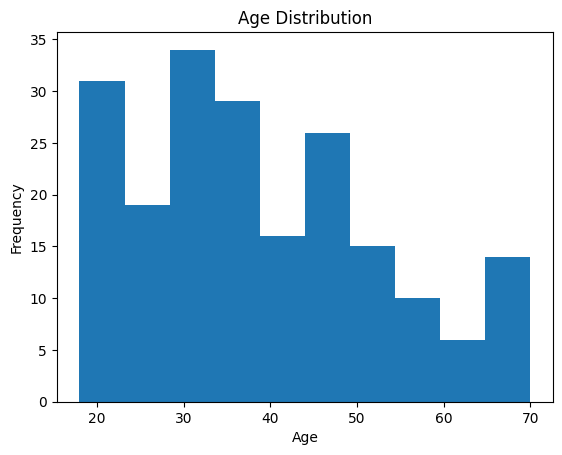

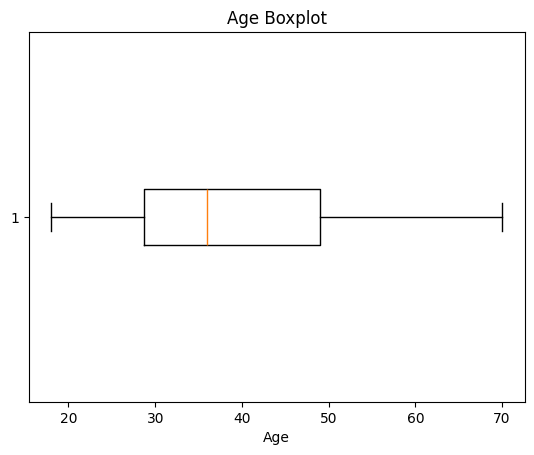

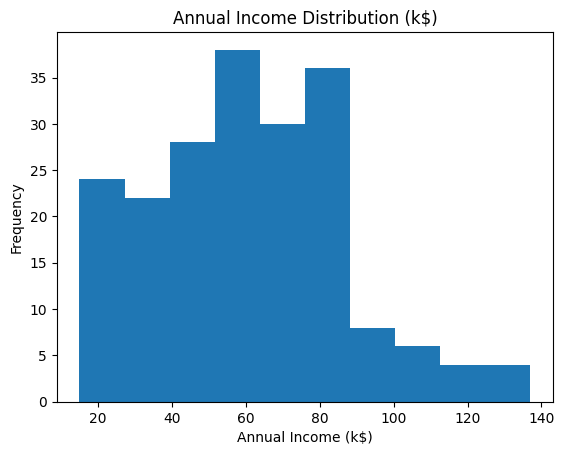

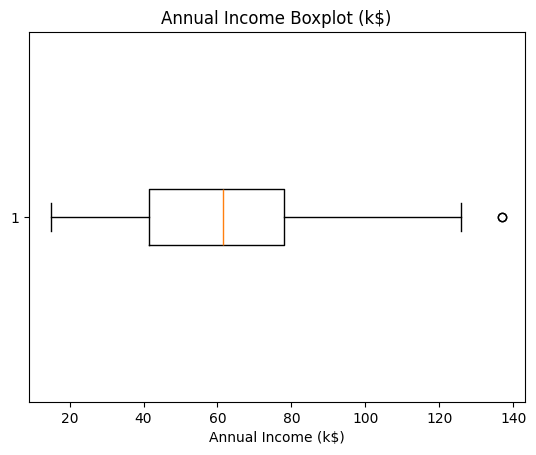

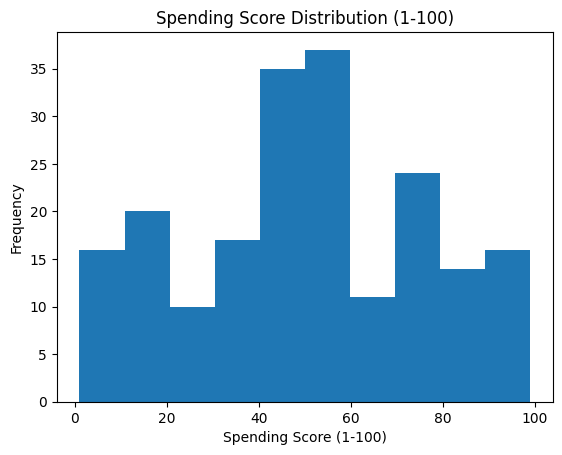

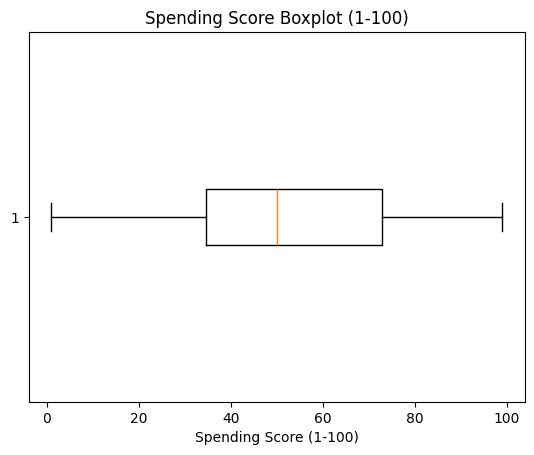

In [3]:
# Cell 3: Univariate Visualizations

import matplotlib.pyplot as plt

# Age histogram
plt.figure()
plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Age boxplot
plt.figure()
plt.boxplot(df['Age'], vert=False)
plt.title('Age Boxplot')
plt.xlabel('Age')
plt.show()

# Annual Income histogram
plt.figure()
plt.hist(df['Annual Income (k$)'])
plt.title('Annual Income Distribution (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

# Annual Income boxplot
plt.figure()
plt.boxplot(df['Annual Income (k$)'], vert=False)
plt.title('Annual Income Boxplot (k$)')
plt.xlabel('Annual Income (k$)')
plt.show()

# Spending Score histogram
plt.figure()
plt.hist(df['Spending Score (1-100)'])
plt.title('Spending Score Distribution (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

# Spending Score boxplot
plt.figure()
plt.boxplot(df['Spending Score (1-100)'], vert=False)
plt.title('Spending Score Boxplot (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.show()


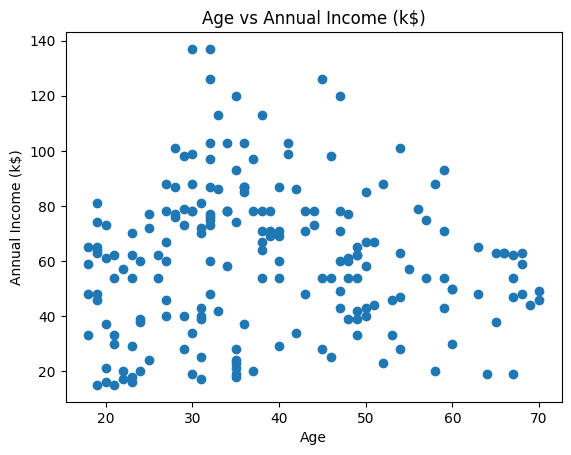

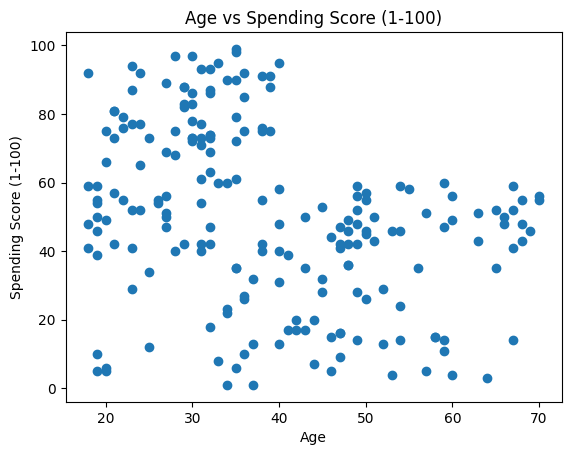

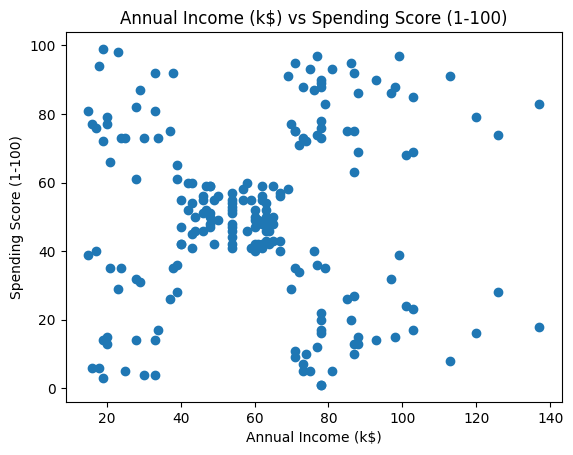

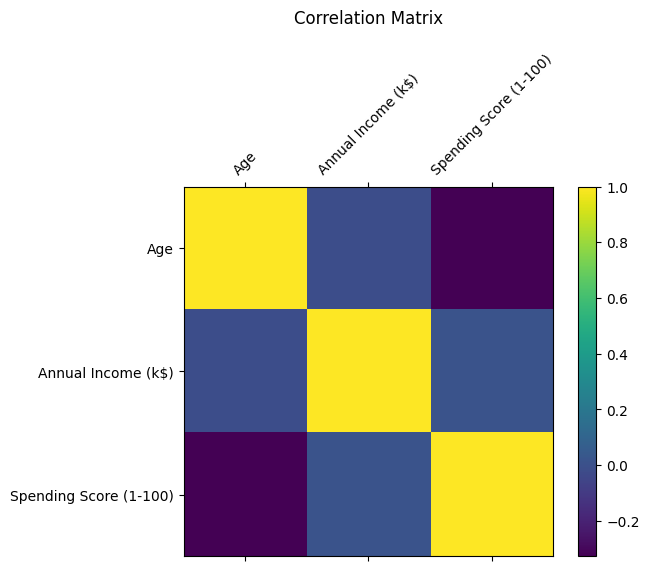

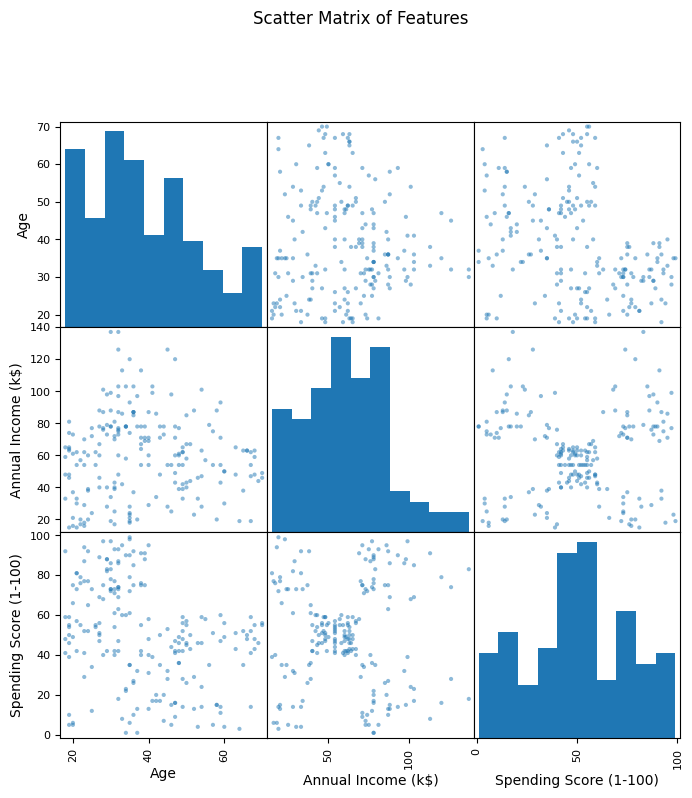

In [27]:
# Cell 4: Bivariate Analysis

from pandas.plotting import scatter_matrix
from itertools import combinations
import matplotlib.pyplot as plt

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Pairwise scatter plots
for x, y in combinations(features, 2):
    plt.figure()
    plt.scatter(df[x], df[y])
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y}')
    plt.show()

# Correlation matrix and heatmap
corr = df[features].corr()
fig, ax = plt.subplots()
cax = ax.matshow(corr)
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)
fig.colorbar(cax)
plt.title('Correlation Matrix', pad=20)
plt.show()

# Pairplot (scatter matrix)
scatter_matrix(df[features], figsize=(8, 8))
plt.suptitle('Scatter Matrix of Features', y=1.02)
plt.show()


PCA Explained Variance Ratio (2 components): [0.44266167 0.33308378]


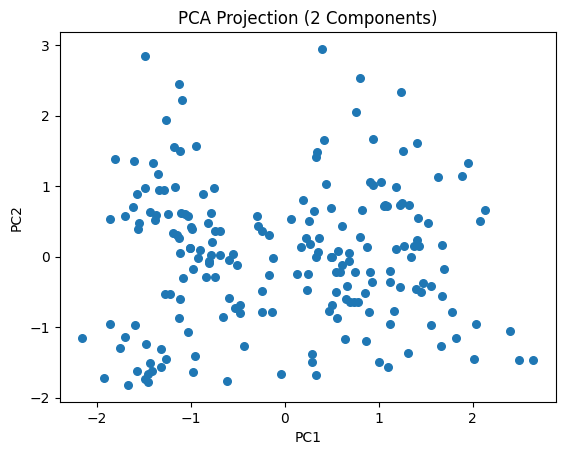

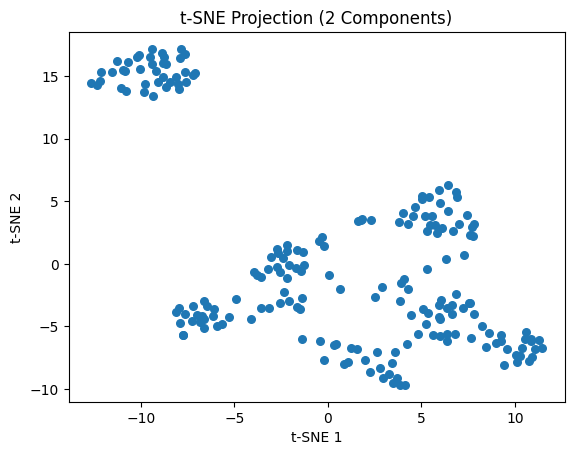

In [28]:
# Cell 5: Dimensionality Reduction (PCA and t-SNE)

# 1. Standardize features
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# 2. PCA to 2 components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print("PCA Explained Variance Ratio (2 components):", explained_variance)

# Scatter plot of PCA result
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=30)
plt.title('PCA Projection (2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# 3. t-SNE embedding
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Scatter plot of t-SNE result
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=30)
plt.title('t-SNE Projection (2 Components)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()


K-Means (k=5) Inertia: 169.89
K-Means (k=5) Silhouette Score: 0.4085


C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


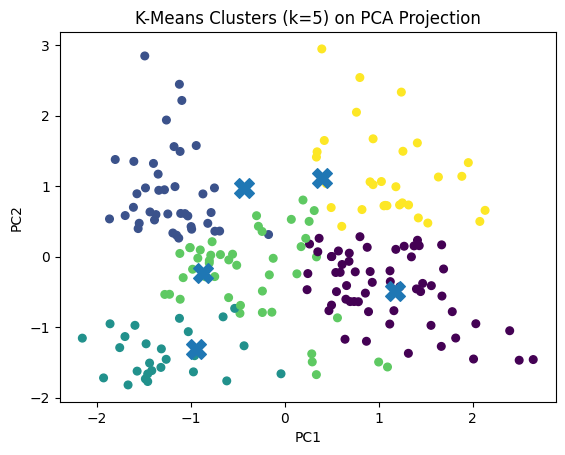

In [6]:
# Cell 6: Baseline K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Fit K-Means
k = 5
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
labels_km = kmeans.fit_predict(X_scaled)

# 2. Compute metrics
inertia_km = kmeans.inertia_
sil_score_km = silhouette_score(X_scaled, labels_km)
print(f'K-Means (k={k}) Inertia: {inertia_km:.2f}')
print(f'K-Means (k={k}) Silhouette Score: {sil_score_km:.4f}')

# 3. Plot clusters on PCA projection
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200)
plt.title(f'K-Means Clusters (k={k}) on PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


PSO Variant 1 (Global-Best) Inertia: 168.25
PSO Variant 1 (Global-Best) Silhouette Score: 0.4166


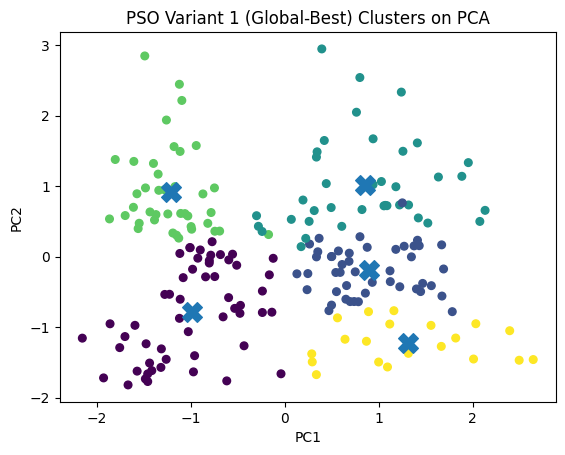

In [7]:
# Cell 7: PSO Variant 1 – Global-Best PSO

def pso_global(X, k, swarm_size=30, max_iters=100, w=0.5, c1=1.5, c2=1.5):
    """Global-best PSO for clustering: returns flattened best centroids and best fitness."""
    n_samples, n_features = X.shape
    dim = k * n_features

    # Feature-wise bounds for initialization
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)

    # Initialize swarm positions and velocities
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.zeros((swarm_size, dim))

    # Personal bests
    pbest_pos = positions.copy()
    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)
    pbest_fit = np.array([fitness(p) for p in positions])

    # Global best
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    # PSO main loop
    for _ in range(max_iters):
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))
        positions += velocities
        positions = np.clip(positions, pos_min, pos_max)

        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]

        min_idx = np.argmin(pbest_fit)
        if pbest_fit[min_idx] < gbest_fit:
            gbest_fit = pbest_fit[min_idx]
            gbest_pos = pbest_pos[min_idx].copy()

    return gbest_pos, gbest_fit

# Execute Variant 1
k = 5
best_pos1, best_fit1 = pso_global(X_scaled, k)
centroids_pso1 = best_pos1.reshape(k, X_scaled.shape[1])
labels_pso1, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso1)

# Compute clustering metrics
inertia_pso1 = np.sum((X_scaled - centroids_pso1[labels_pso1])**2)
silhouette_pso1 = silhouette_score(X_scaled, labels_pso1)
print(f'PSO Variant 1 (Global-Best) Inertia: {inertia_pso1:.2f}')
print(f'PSO Variant 1 (Global-Best) Silhouette Score: {silhouette_pso1:.4f}')

# Plot on PCA projection
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso1, s=30)
centroids_pca1 = pca.transform(centroids_pso1)
plt.scatter(centroids_pca1[:, 0], centroids_pca1[:, 1], marker='X', s=200)
plt.title('PSO Variant 1 (Global-Best) Clusters on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


PSO Variant 2 (Local-Best) Inertia: 169.59
PSO Variant 2 (Local-Best) Silhouette Score: 0.4151


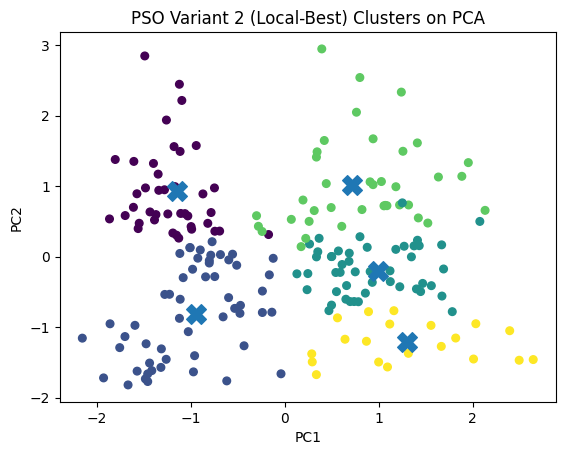

In [8]:
# Cell 8: PSO Variant 2 – Local-Best (Ring Topology) PSO

def pso_local(X, k, swarm_size=30, max_iters=100, w=0.5, c1=1.5, c2=1.5):
    """Local-best PSO for clustering with ring neighborhood: returns best centroids and fitness."""
    n_samples, n_features = X.shape
    dim = k * n_features

    # Feature-wise bounds
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)

    # Initialize positions & velocities
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.zeros((swarm_size, dim))

    # Personal bests
    pbest_pos = positions.copy()
    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)
    pbest_fit = np.array([fitness(p) for p in positions])

    # Local best positions (initially same as personal)
    lbest_pos = pbest_pos.copy()
    lbest_fit = pbest_fit.copy()

    # Update local best for each particle's ring neighborhood
    def update_local_bests():
        for i in range(swarm_size):
            neighbors = [(i-1) % swarm_size, i, (i+1) % swarm_size]
            best_idx = min(neighbors, key=lambda idx: pbest_fit[idx])
            lbest_pos[i] = pbest_pos[best_idx]
            lbest_fit[i] = pbest_fit[best_idx]

    update_local_bests()

    # PSO main loop
    for _ in range(max_iters):
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (lbest_pos - positions))
        positions += velocities
        positions = np.clip(positions, pos_min, pos_max)

        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]
        update_local_bests()

    # Choose best among all personal bests
    best_idx = np.argmin(pbest_fit)
    return pbest_pos[best_idx], pbest_fit[best_idx]

# Execute Variant 2
best_pos2, best_fit2 = pso_local(X_scaled, k)
centroids_pso2 = best_pos2.reshape(k, X_scaled.shape[1])
labels_pso2, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso2)

# Metrics
inertia_pso2 = np.sum((X_scaled - centroids_pso2[labels_pso2])**2)
silhouette_pso2 = silhouette_score(X_scaled, labels_pso2)
print(f'PSO Variant 2 (Local-Best) Inertia: {inertia_pso2:.2f}')
print(f'PSO Variant 2 (Local-Best) Silhouette Score: {silhouette_pso2:.4f}')

# Plot clusters on PCA
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso2, s=30)
centroids_pca2 = pca.transform(centroids_pso2)
plt.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1], marker='X', s=200)
plt.title('PSO Variant 2 (Local-Best) Clusters on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


PSO Variant 3 (Linear Inertia) Inertia: 198.66
PSO Variant 3 (Linear Inertia) Silhouette Score: 0.3786


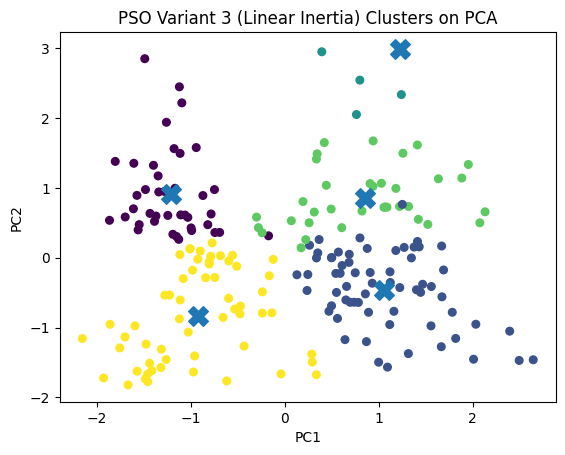

In [9]:
# Cell 9: PSO Variant 3 – Linearly Decreasing Inertia PSO

def pso_linear_inertia(X, k, swarm_size=30, max_iters=100, w_max=0.9, w_min=0.4, c1=1.5, c2=1.5):
    """PSO with linearly decreasing inertia weight."""
    n_samples, n_features = X.shape
    dim = k * n_features
    
    # Bounds
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)
    
    # Initialize
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.zeros((swarm_size, dim))
    pbest_pos = positions.copy()
    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)
    pbest_fit = np.array([fitness(p) for p in positions])
    
    # Global best init
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]
    
    # Main loop
    for iter in range(max_iters):
        # Update inertia
        w = w_max - (w_max - w_min) * (iter / (max_iters - 1))
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))
        positions += velocities
        positions = np.clip(positions, pos_min, pos_max)
        
        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]
        
        min_idx = np.argmin(pbest_fit)
        if pbest_fit[min_idx] < gbest_fit:
            gbest_fit = pbest_fit[min_idx]
            gbest_pos = pbest_pos[min_idx].copy()
    
    return gbest_pos, gbest_fit

# Execute Variant 3
best_pos3, best_fit3 = pso_linear_inertia(X_scaled, k)
centroids_pso3 = best_pos3.reshape(k, X_scaled.shape[1])
labels_pso3, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso3)

# Metrics
inertia_pso3 = np.sum((X_scaled - centroids_pso3[labels_pso3])**2)
silhouette_pso3 = silhouette_score(X_scaled, labels_pso3)
print(f'PSO Variant 3 (Linear Inertia) Inertia: {inertia_pso3:.2f}')
print(f'PSO Variant 3 (Linear Inertia) Silhouette Score: {silhouette_pso3:.4f}')

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso3, s=30)
centroids_pca3 = pca.transform(centroids_pso3)
plt.scatter(centroids_pca3[:, 0], centroids_pca3[:, 1], marker='X', s=200)
plt.title('PSO Variant 3 (Linear Inertia) Clusters on PCA')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()


PSO Variant 4 (Constriction-Factor) Inertia: 168.77
PSO Variant 4 (Constriction-Factor) Silhouette Score: 0.4115


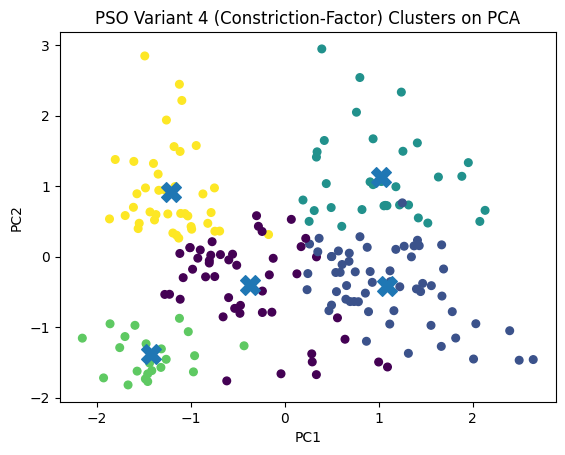

In [10]:
# Cell 10: PSO Variant 4 – Constriction-Factor PSO

import math

def pso_constriction(X, k, swarm_size=30, max_iters=100, c1=2.05, c2=2.05):
    """PSO with constriction factor (Clerc's constriction coefficient)."""
    n_samples, n_features = X.shape
    dim = k * n_features
    
    # Bounds
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)
    
    # Calculate constriction coefficient
    phi = c1 + c2
    chi = 2 / abs(2 - phi - math.sqrt(phi**2 - 4*phi))
    
    # Initialize
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.zeros((swarm_size, dim))
    pbest_pos = positions.copy()
    
    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)
    
    pbest_fit = np.array([fitness(p) for p in positions])
    # Global best
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]
    
    # PSO loop
    for _ in range(max_iters):
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = chi * (velocities
                            + c1 * r1 * (pbest_pos - positions)
                            + c2 * r2 * (gbest_pos - positions))
        positions += velocities
        positions = np.clip(positions, pos_min, pos_max)
        
        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]
        
        min_idx = np.argmin(pbest_fit)
        if pbest_fit[min_idx] < gbest_fit:
            gbest_fit = pbest_fit[min_idx]
            gbest_pos = pbest_pos[min_idx].copy()
    
    return gbest_pos, gbest_fit

# Execute Variant 4
best_pos4, best_fit4 = pso_constriction(X_scaled, k)
centroids_pso4 = best_pos4.reshape(k, X_scaled.shape[1])
labels_pso4, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso4)

# Metrics
inertia_pso4 = np.sum((X_scaled - centroids_pso4[labels_pso4])**2)
silhouette_pso4 = silhouette_score(X_scaled, labels_pso4)
print(f'PSO Variant 4 (Constriction-Factor) Inertia: {inertia_pso4:.2f}')
print(f'PSO Variant 4 (Constriction-Factor) Silhouette Score: {silhouette_pso4:.4f}')

# Plot on PCA
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso4, s=30)
centroids_pca4 = pca.transform(centroids_pso4)
plt.scatter(centroids_pca4[:, 0], centroids_pca4[:, 1], marker='X', s=200)
plt.title('PSO Variant 4 (Constriction-Factor) Clusters on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


PSO Variant 5 (Velocity-Clamped) Inertia: 195.06
PSO Variant 5 (Velocity-Clamped) Silhouette Score: 0.3647


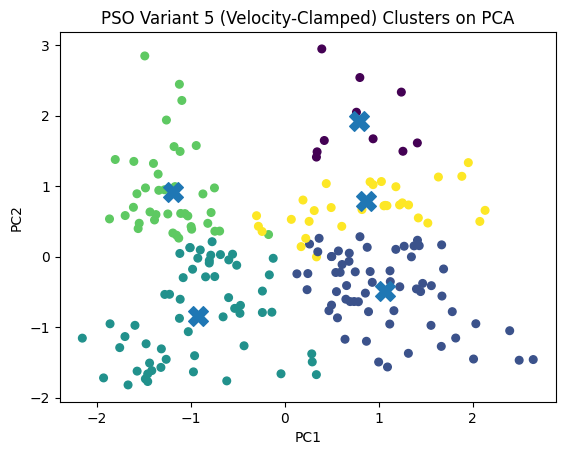

In [11]:
# Cell 11: PSO Variant 5 – Velocity-Clamped PSO

def pso_velocity_clamped(X, k, swarm_size=30, max_iters=100, w=0.5, c1=1.5, c2=1.5, vmax_frac=0.2):
    """PSO with velocity clamping."""
    n_samples, n_features = X.shape
    dim = k * n_features

    # Bounds
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)

    # Max velocity per dimension
    vmax = (pos_max - pos_min) * vmax_frac

    # Initialize
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.random.uniform(-vmax, vmax, (swarm_size, dim))
    pbest_pos = positions.copy()

    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)

    pbest_fit = np.array([fitness(p) for p in positions])
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    for _ in range(max_iters):
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))

        # Clamp velocities
        velocities = np.clip(velocities, -vmax, vmax)

        positions += velocities
        positions = np.clip(positions, pos_min, pos_max)

        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]

        min_idx = np.argmin(pbest_fit)
        if pbest_fit[min_idx] < gbest_fit:
            gbest_fit = pbest_fit[min_idx]
            gbest_pos = pbest_pos[min_idx].copy()

    return gbest_pos, gbest_fit

# Execute Variant 5
best_pos5, best_fit5 = pso_velocity_clamped(X_scaled, k)
centroids_pso5 = best_pos5.reshape(k, X_scaled.shape[1])
labels_pso5, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso5)

# Metrics
inertia_pso5 = np.sum((X_scaled - centroids_pso5[labels_pso5])**2)
silhouette_pso5 = silhouette_score(X_scaled, labels_pso5)
print(f'PSO Variant 5 (Velocity-Clamped) Inertia: {inertia_pso5:.2f}')
print(f'PSO Variant 5 (Velocity-Clamped) Silhouette Score: {silhouette_pso5:.4f}')

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso5, s=30)
centroids_pca5 = pca.transform(centroids_pso5)
plt.scatter(centroids_pca5[:, 0], centroids_pca5[:, 1], marker='X', s=200)
plt.title('PSO Variant 5 (Velocity-Clamped) Clusters on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


PSO Variant 6 (PSO + Mutation) Inertia: 205.23
PSO Variant 6 (PSO + Mutation) Silhouette Score: 0.4040


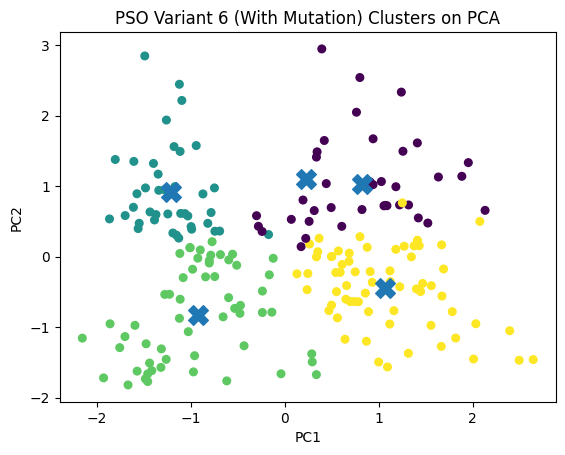

In [12]:
# Cell 12: PSO Variant 6 – PSO with Gaussian Mutation

def pso_mutation(X, k, swarm_size=30, max_iters=100, w=0.5, c1=1.5, c2=1.5, mutation_prob=0.2, mutation_scale=0.05):
    """PSO with Gaussian mutation injected into particles."""
    n_samples, n_features = X.shape
    dim = k * n_features

    # Bounds
    data_min = X.min(axis=0)
    data_max = X.max(axis=0)
    pos_min = np.tile(data_min, k)
    pos_max = np.tile(data_max, k)

    # Initialize
    positions = np.random.uniform(pos_min, pos_max, (swarm_size, dim))
    velocities = np.zeros((swarm_size, dim))
    pbest_pos = positions.copy()

    def fitness(pos):
        centers = pos.reshape(k, n_features)
        _, dists = pairwise_distances_argmin_min(X, centers)
        return np.sum(dists**2)

    pbest_fit = np.array([fitness(p) for p in positions])
    gbest_idx = np.argmin(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    for _ in range(max_iters):
        r1 = np.random.rand(swarm_size, dim)
        r2 = np.random.rand(swarm_size, dim)
        velocities = (w * velocities
                      + c1 * r1 * (pbest_pos - positions)
                      + c2 * r2 * (gbest_pos - positions))
        positions += velocities

        # Inject Gaussian mutation into a subset of particles
        for i in range(swarm_size):
            if np.random.rand() < mutation_prob:
                mutation = np.random.normal(0, mutation_scale, dim)
                positions[i] += mutation

        positions = np.clip(positions, pos_min, pos_max)

        fitness_vals = np.array([fitness(p) for p in positions])
        improved = fitness_vals < pbest_fit
        pbest_pos[improved] = positions[improved]
        pbest_fit[improved] = fitness_vals[improved]

        min_idx = np.argmin(pbest_fit)
        if pbest_fit[min_idx] < gbest_fit:
            gbest_fit = pbest_fit[min_idx]
            gbest_pos = pbest_pos[min_idx].copy()

    return gbest_pos, gbest_fit

# Execute Variant 6
best_pos6, best_fit6 = pso_mutation(X_scaled, k)
centroids_pso6 = best_pos6.reshape(k, X_scaled.shape[1])
labels_pso6, _ = pairwise_distances_argmin_min(X_scaled, centroids_pso6)

# Metrics
inertia_pso6 = np.sum((X_scaled - centroids_pso6[labels_pso6])**2)
silhouette_pso6 = silhouette_score(X_scaled, labels_pso6)
print(f'PSO Variant 6 (PSO + Mutation) Inertia: {inertia_pso6:.2f}')
print(f'PSO Variant 6 (PSO + Mutation) Silhouette Score: {silhouette_pso6:.4f}')

# Plot clusters on PCA
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pso6, s=30)
centroids_pca6 = pca.transform(centroids_pso6)
plt.scatter(centroids_pca6[:, 0], centroids_pca6[:, 1], marker='X', s=200)
plt.title('PSO Variant 6 (With Mutation) Clusters on PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


,Method,Inertia,Silhouette Score
0,KMeans,169.8915,0.4085
1,PSO - Global Best,168.2477,0.4166
2,PSO - Local Best,169.5944,0.4151
3,PSO - Linear Inertia,198.6573,0.3786
4,PSO - Constriction Factor,168.7666,0.4115
5,PSO - Velocity Clamped,195.0623,0.3647
6,PSO - Mutation,205.2293,0.4040


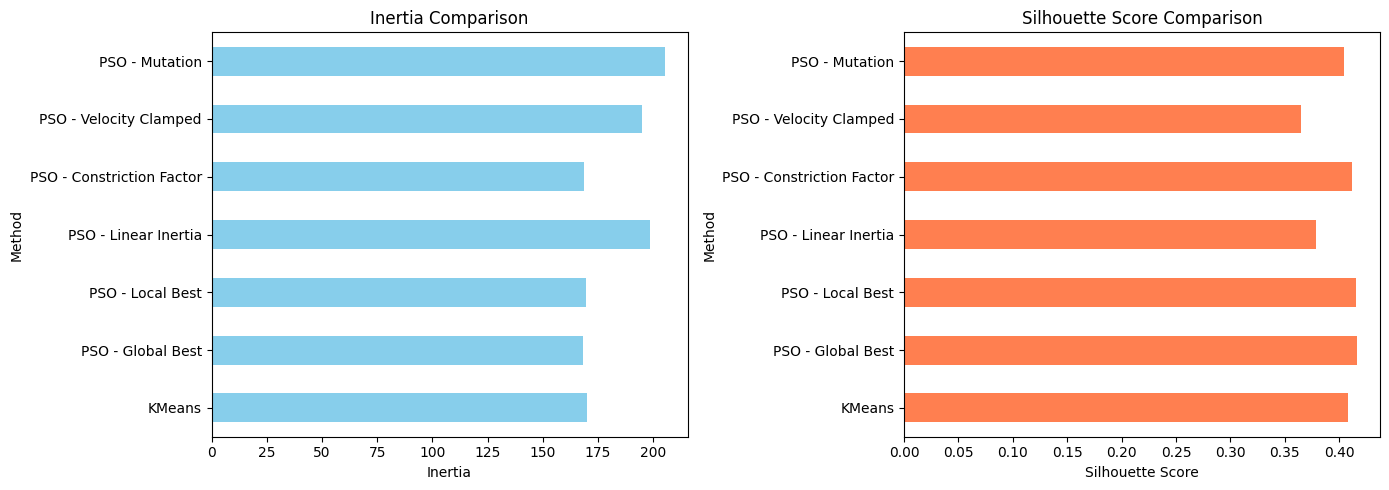

In [13]:
# Cell 13: Comparative Analysis – PSO Variants + KMeans

# Compile performance metrics
results = pd.DataFrame({
    'Method': [
        'KMeans',
        'PSO - Global Best',
        'PSO - Local Best',
        'PSO - Linear Inertia',
        'PSO - Constriction Factor',
        'PSO - Velocity Clamped',
        'PSO - Mutation'
    ],
    'Inertia': [
        inertia_km,
        inertia_pso1,
        inertia_pso2,
        inertia_pso3,
        inertia_pso4,
        inertia_pso5,
        inertia_pso6
    ],
    'Silhouette Score': [
        sil_score_km,
        silhouette_pso1,
        silhouette_pso2,
        silhouette_pso3,
        silhouette_pso4,
        silhouette_pso5,
        silhouette_pso6
    ]
})

# Display table
display(results.round(4))

# Bar plot for comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

results.plot(x='Method', y='Inertia', kind='barh', ax=ax[0], legend=False, color='skyblue')
ax[0].set_title('Inertia Comparison')
ax[0].set_xlabel('Inertia')

results.plot(x='Method', y='Silhouette Score', kind='barh', ax=ax[1], legend=False, color='coral')
ax[1].set_title('Silhouette Score Comparison')
ax[1].set_xlabel('Silhouette Score')

plt.tight_layout()
plt.show()


C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:14

,Method,Inertia Mean,Inertia Std,Silhouette Mean,Silhouette Std
0,KMeans,171.2923,6.2844,0.4043,0.0195
1,PSO - Global Best,175.6102,10.0599,0.4012,0.0194
2,PSO - Local Best,170.8386,2.5856,0.4115,0.0069
3,PSO - Linear Inertia,178.3760,12.7495,0.4021,0.0198
4,PSO - Constriction Factor,175.4803,12.5514,0.4073,0.0136
5,PSO - Velocity Clamped,171.5784,5.0052,0.4042,0.0195
6,PSO - Mutation,170.8510,7.1847,0.4091,0.0156


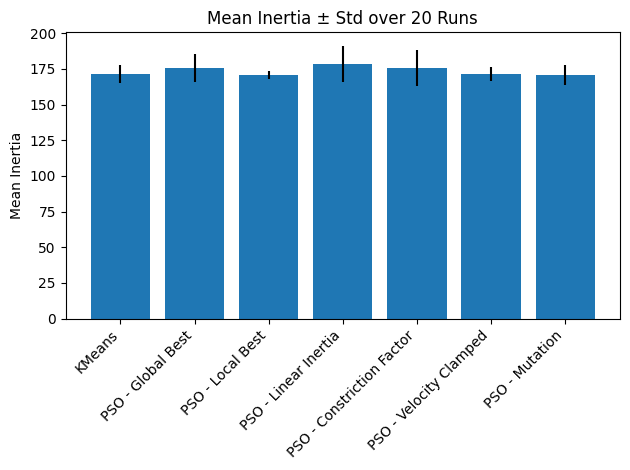

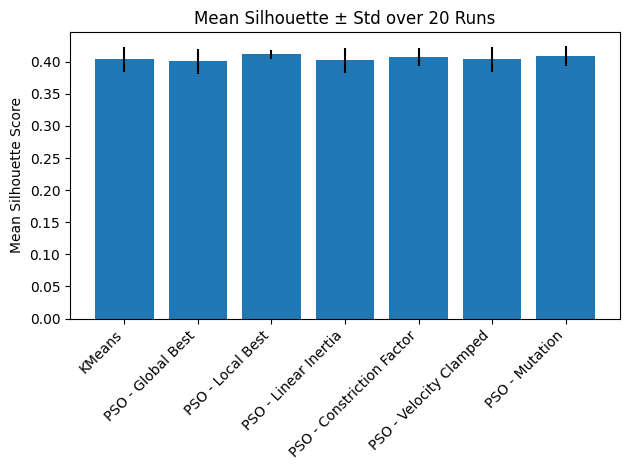

In [19]:
# Cell 14: Multi-Run Evaluation of Methods

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances_argmin_min

# Ensure reproducibility base
BASE_SEED = RANDOM_STATE
RUNS = 20

# Wrapper functions for each method
def run_kmeans(seed):
    np.random.seed(seed)
    km = KMeans(n_clusters=k, random_state=seed)
    labels = km.fit_predict(X_scaled)
    return km.inertia_, silhouette_score(X_scaled, labels)

def run_pso_global_best(seed):
    np.random.seed(seed)
    best_pos, _ = pso_global(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

def run_pso_local_best(seed):
    np.random.seed(seed)
    best_pos, _ = pso_local(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

def run_pso_linear_inertia(seed):
    np.random.seed(seed)
    best_pos, _ = pso_linear_inertia(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

def run_pso_constriction(seed):
    np.random.seed(seed)
    best_pos, _ = pso_constriction(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

def run_pso_velocity_clamped(seed):
    np.random.seed(seed)
    best_pos, _ = pso_velocity_clamped(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

def run_pso_mutation(seed):
    np.random.seed(seed)
    best_pos, _ = pso_mutation(X_scaled, k)
    centers = best_pos.reshape(k, X_scaled.shape[1])
    labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
    return np.sum((X_scaled - centers[labels])**2), silhouette_score(X_scaled, labels)

methods = {
    'KMeans': run_kmeans,
    'PSO - Global Best': run_pso_global_best,
    'PSO - Local Best': run_pso_local_best,
    'PSO - Linear Inertia': run_pso_linear_inertia,
    'PSO - Constriction Factor': run_pso_constriction,
    'PSO - Velocity Clamped': run_pso_velocity_clamped,
    'PSO - Mutation': run_pso_mutation
}

# Evaluation function
def evaluate(func, runs=RUNS):
    inerts, sils = [], []
    for i in range(runs):
        seed = BASE_SEED + i
        inert, sil = func(seed)
        inerts.append(inert)
        sils.append(sil)
    return np.mean(inerts), np.std(inerts), np.mean(sils), np.std(sils)

# Run evaluation
results = []
for name, func in methods.items():
    m_in, s_in, m_sil, s_sil = evaluate(func)
    results.append({
        'Method': name,
        'Inertia Mean': m_in,
        'Inertia Std': s_in,
        'Silhouette Mean': m_sil,
        'Silhouette Std': s_sil
    })

df_results = pd.DataFrame(results)
display(df_results.round(4))

# Plot Inertia with error bars
plt.figure()
plt.bar(df_results['Method'], df_results['Inertia Mean'], yerr=df_results['Inertia Std'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Inertia')
plt.title('Mean Inertia ± Std over 20 Runs')
plt.tight_layout()
plt.show()

# Plot Silhouette with error bars
plt.figure()
plt.bar(df_results['Method'], df_results['Silhouette Mean'], yerr=df_results['Silhouette Std'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Silhouette Score')
plt.title('Mean Silhouette ± Std over 20 Runs')
plt.tight_layout()
plt.show()


,Method,Best Silhouette,Best Inertia,Best Params
0,PSO - Global Best,0.416643,168.247580,"{'swarm_size': 50, 'max_iters': 100}"
1,PSO - Local Best,0.418319,169.673839,"{'swarm_size': 30, 'max_iters': 100}"
2,PSO - Linear Inertia,0.416643,168.247582,"{'swarm_size': 30, 'max_iters': 200}"
3,PSO - Constriction Factor,0.418235,171.810178,"{'swarm_size': 30, 'max_iters': 100}"
4,PSO - Velocity Clamped,0.416643,168.247600,"{'swarm_size': 50, 'max_iters': 200, 'vmax_fra..."
5,PSO - Mutation,0.416643,168.247583,"{'swarm_size': 50, 'max_iters': 200, 'mutation..."


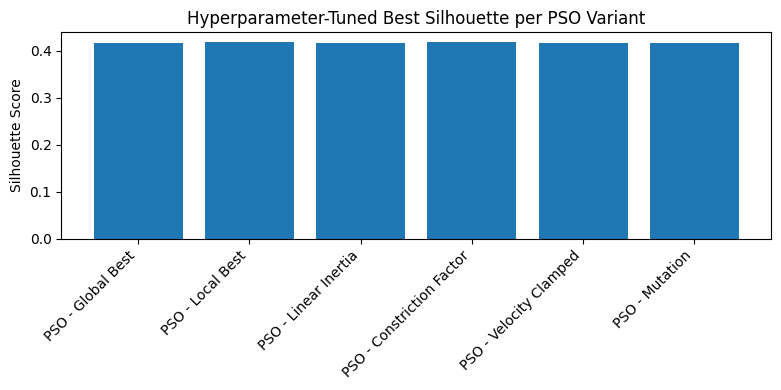

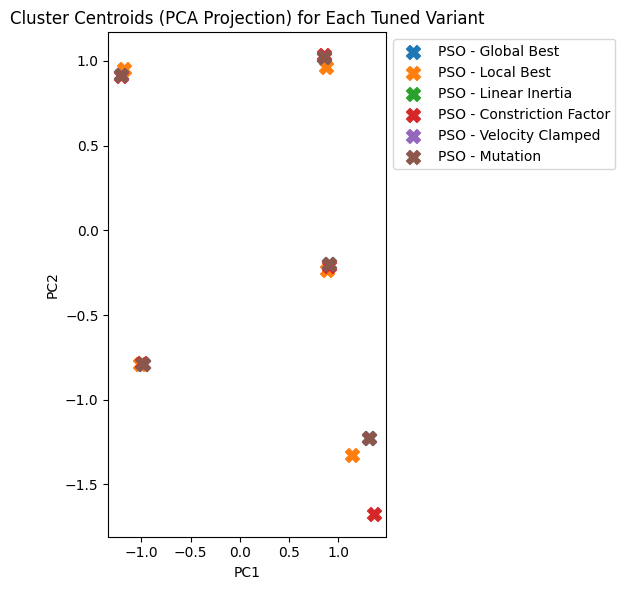

In [20]:
# Cell 15: Hyperparameter Tuning for All Variants & Centroid Visualization

from itertools import product

# Define hyperparameter grids for each PSO variant
param_grids = {
    'PSO - Global Best':      {'swarm_size': [30, 50], 'max_iters': [100, 200]},
    'PSO - Local Best':       {'swarm_size': [30, 50], 'max_iters': [100, 200]},
    'PSO - Linear Inertia':   {'swarm_size': [30, 50], 'max_iters': [100, 200]},
    'PSO - Constriction Factor': {'swarm_size': [30, 50], 'max_iters': [100, 200]},
    'PSO - Velocity Clamped': {'swarm_size': [30, 50], 'max_iters': [100, 200], 'vmax_frac': [0.1, 0.2]},
    'PSO - Mutation':         {'swarm_size': [30, 50], 'max_iters': [100, 200], 'mutation_prob': [0.1, 0.2]}
}

# Map method names to functions
variant_funcs = {
    'PSO - Global Best':      pso_global,
    'PSO - Local Best':       pso_local,
    'PSO - Linear Inertia':   pso_linear_inertia,
    'PSO - Constriction Factor': pso_constriction,
    'PSO - Velocity Clamped': pso_velocity_clamped,
    'PSO - Mutation':         pso_mutation
}

# Store best results
tune_results = []

for name, fn in variant_funcs.items():
    grid = param_grids[name]
    keys = list(grid.keys())
    best_sil, best_inert = -np.inf, np.inf
    best_centers, best_params = None, None

    # Iterate hyperparameter combinations
    for combo in product(*grid.values()):
        params = dict(zip(keys, combo))
        # Run variant with these hyperparameters
        centers_flat, _ = fn(X_scaled, k, **params)
        centers = centers_flat.reshape(k, X_scaled.shape[1])
        labels, _ = pairwise_distances_argmin_min(X_scaled, centers)
        sil = silhouette_score(X_scaled, labels)
        inert = np.sum((X_scaled - centers[labels])**2)

        # Select by highest silhouette, then lowest inertia
        if (sil > best_sil) or (sil == best_sil and inert < best_inert):
            best_sil, best_inert = sil, inert
            best_centers = centers
            best_params = params

    tune_results.append({
        'Method': name,
        'Best Silhouette': best_sil,
        'Best Inertia': best_inert,
        'Best Params': best_params,
        'Centroids': best_centers
    })

# Create DataFrame and display
df_tune = pd.DataFrame([{k: v for k, v in r.items() if k != 'Centroids'} for r in tune_results])
display(df_tune)

# Plot Best Silhouette for each variant
plt.figure(figsize=(8, 4))
plt.bar(df_tune['Method'], df_tune['Best Silhouette'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Silhouette Score')
plt.title('Hyperparameter-Tuned Best Silhouette per PSO Variant')
plt.tight_layout()
plt.show()

# Plot all centroids in PCA space
plt.figure(figsize=(6, 6))
for r in tune_results:
    centers_pca = pca.transform(r['Centroids'])
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=100, label=r['Method'])
plt.title('Cluster Centroids (PCA Projection) for Each Tuned Variant')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


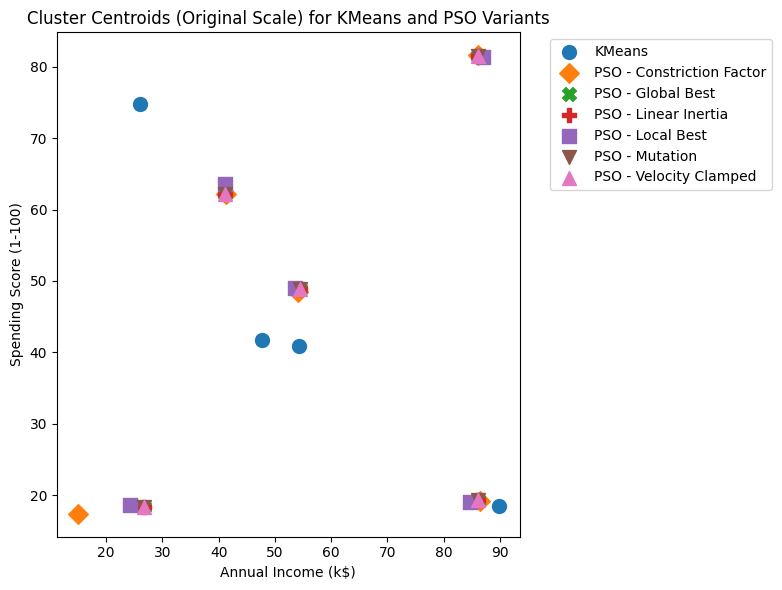

In [21]:
# Cell 17: Plot Best-Tuned Centroids for PSO Variants and KMeans

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Prepare PSO centroids (inverse-transform to original scale)
centroid_rows = []
for result in tune_results:
    method = result['Method']
    centers_scaled = result['Centroids']  # in scaled space
    centers_orig = scaler.inverse_transform(centers_scaled)
    for cid, center in enumerate(centers_orig):
        centroid_rows.append({
            'Method': method,
            'Cluster': cid,
            'Age': center[0],
            'Annual Income (k$)': center[1],
            'Spending Score (1-100)': center[2]
        })

# 2. Add KMeans centroids
km = KMeans(n_clusters=k, random_state=RANDOM_STATE)
km_labels = km.fit_predict(X_scaled)
# Inverse-transform KMeans centers
km_centers_orig = scaler.inverse_transform(km.cluster_centers_)
for cid, center in enumerate(km_centers_orig):
    centroid_rows.append({
        'Method': 'KMeans',
        'Cluster': cid,
        'Age': center[0],
        'Annual Income (k$)': center[1],
        'Spending Score (1-100)': center[2]
    })

# Create DataFrame
df_centroids_all = pd.DataFrame(centroid_rows)

# Plot centroids: Annual Income vs. Spending Score
plt.figure(figsize=(8, 6))
styles = {'KMeans': 'o', 
          'PSO - Global Best': 'X', 
          'PSO - Local Best': 's',
          'PSO - Linear Inertia': 'P',
          'PSO - Constriction Factor': 'D',
          'PSO - Velocity Clamped': '^',
          'PSO - Mutation': 'v'}

for method, df_group in df_centroids_all.groupby('Method'):
    plt.scatter(df_group['Annual Income (k$)'], 
                df_group['Spending Score (1-100)'],
                label=method, marker=styles.get(method, 'o'), s=100)

plt.title('Cluster Centroids (Original Scale) for KMeans and PSO Variants')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


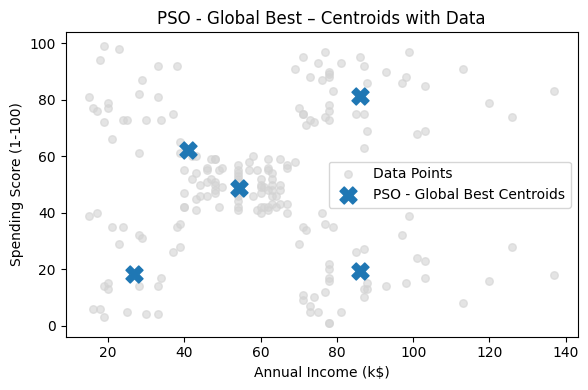

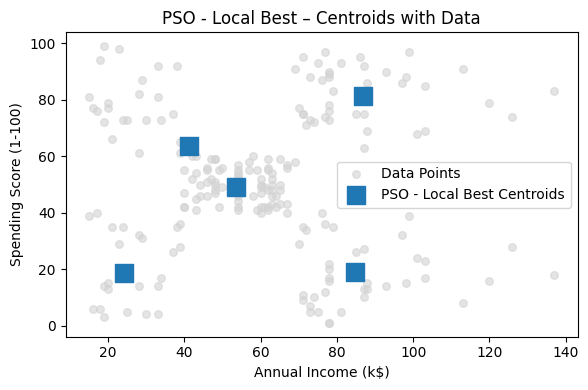

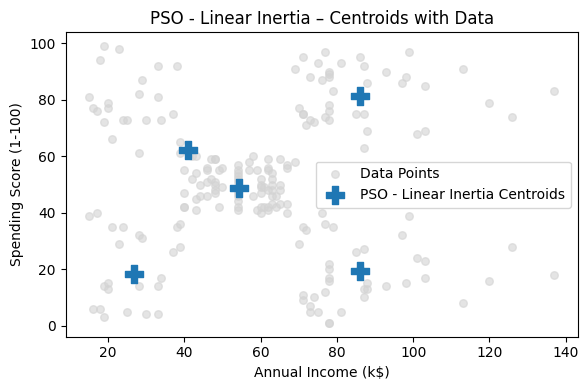

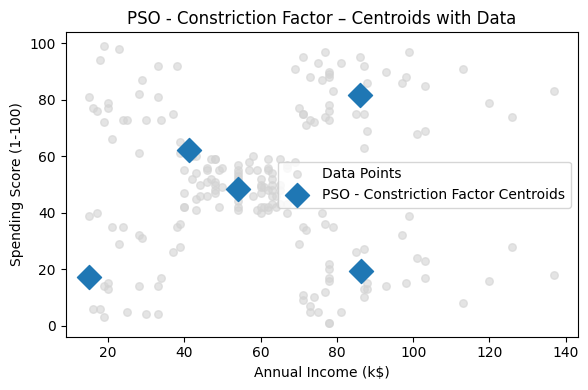

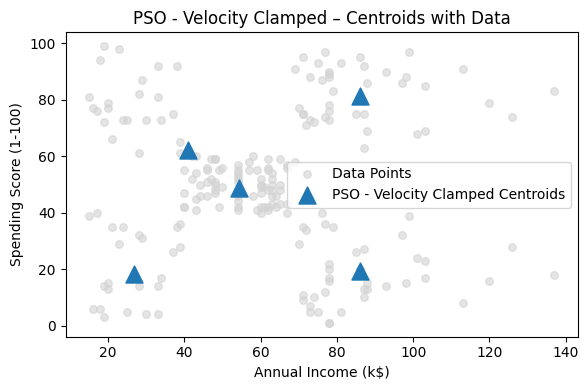

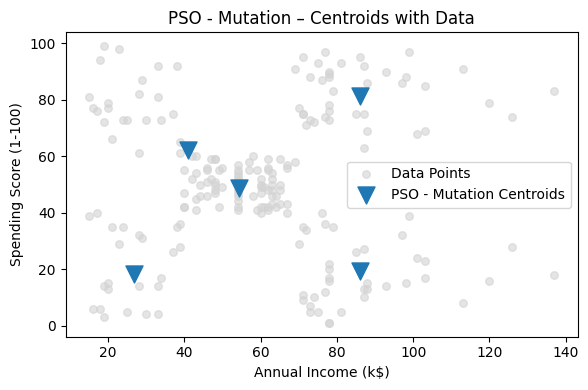

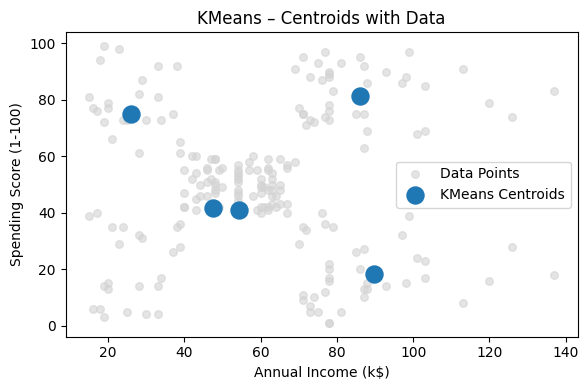

In [22]:
# Cell 19: Plot Each Variation’s Centroids with Data Points

# Use original (unscaled) data
df_orig = df.copy()

# Iterate and plot each variant with its centroids + data points
for method in df_centroids_all['Method'].unique():
    df_sub = df_centroids_all[df_centroids_all['Method'] == method]
    
    plt.figure(figsize=(6, 4))
    
    # Plot original data points
    plt.scatter(
        df_orig['Annual Income (k$)'],
        df_orig['Spending Score (1-100)'],
        color='lightgray',
        label='Data Points',
        s=30,
        alpha=0.6
    )
    
    # Plot centroids
    plt.scatter(
        df_sub['Annual Income (k$)'],
        df_sub['Spending Score (1-100)'],
        marker=styles.get(method, 'o'),
        s=150,
        label=f'{method} Centroids'
    )
    
    plt.title(f'{method} – Centroids with Data')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score (1-100)')
    plt.legend()
    plt.tight_layout()
    plt.show()


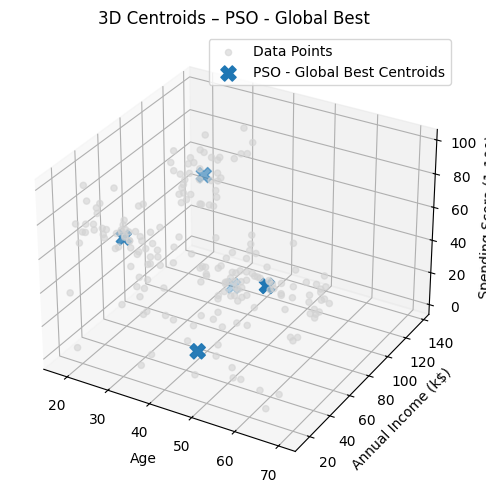

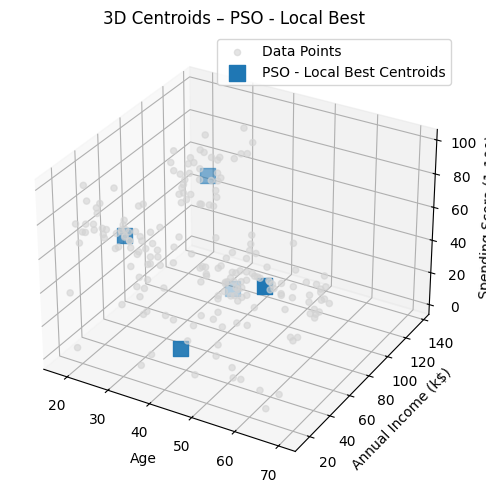

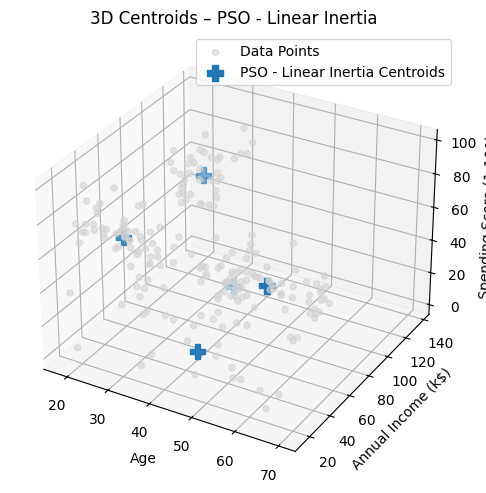

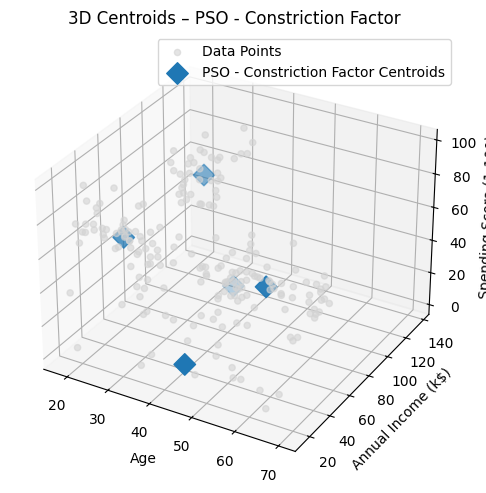

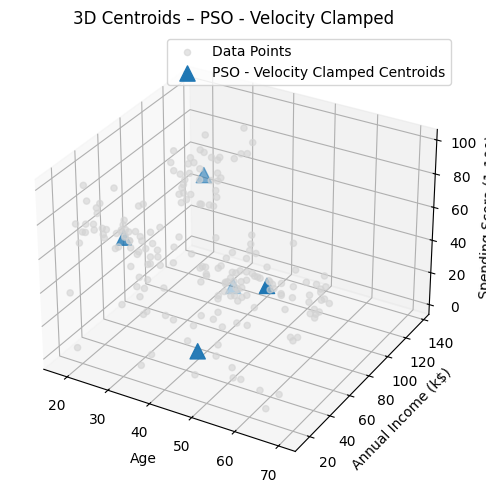

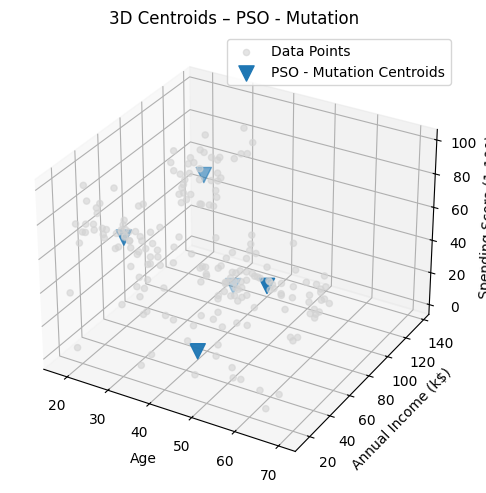

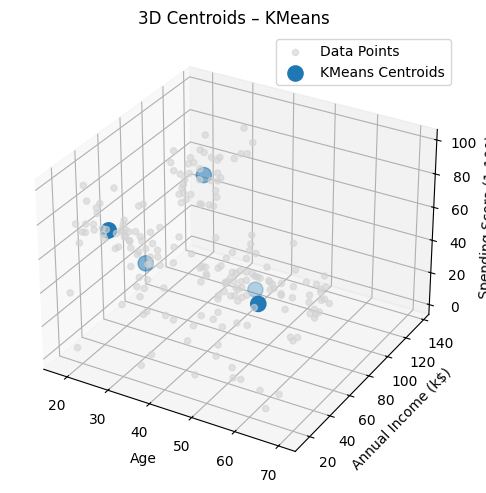

In [23]:
# Cell 20: 3D Plot of Centroids and Data Points for Each Method

from mpl_toolkits.mplot3d import Axes3D

# Extract original data
X3d = df_orig[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# Iterate and create 3D scatter plots
for method in df_centroids_all['Method'].unique():
    df_sub = df_centroids_all[df_centroids_all['Method'] == method]
    
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot all original data points
    ax.scatter(X3d[:, 0], X3d[:, 1], X3d[:, 2],
               c='lightgray', s=20, alpha=0.6, label='Data Points')
    
    # Plot centroids
    ax.scatter(
        df_sub['Age'],
        df_sub['Annual Income (k$)'],
        df_sub['Spending Score (1-100)'],
        s=120,
        label=f'{method} Centroids',
        marker=styles.get(method, 'o')
    )
    
    ax.set_title(f'3D Centroids – {method}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Annual Income (k$)')
    ax.set_zlabel('Spending Score (1-100)')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [2]:
import sys
import pandas as pd
import numpy as np
from PyQt5.QtWidgets import QApplication, QMainWindow, QWidget, QVBoxLayout, QHBoxLayout, QFormLayout, QLabel, QLineEdit, QComboBox, QPushButton, QFrame, QFileDialog
from PyQt5.QtCore import Qt
from matplotlib.backends.backend_qt5agg import FigureCanvasQTAgg as FigureCanvas
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from data import process
import functions2 as f

class PSOClusteringGUI(QMainWindow):
    def __init__(self, X, offerings, default_params):
        super().__init__()
        self.X = X
        self.offerings = offerings
        self.default_params = default_params
        self.init_ui()

    def init_ui(self):
        self.setWindowTitle('PSO Clustering')
        central = QWidget()
        main_layout = QVBoxLayout()

        # Method selection
        method_layout = QHBoxLayout()
        method_layout.addWidget(QLabel('Select Method:'))
        self.method_combo = QComboBox()
        self.method_combo.addItems(list(self.offerings.keys()))
        self.method_combo.currentTextChanged.connect(self.update_params)
        method_layout.addWidget(self.method_combo)
        main_layout.addLayout(method_layout)

        # Parameter area
        self.param_frame = QFrame()
        self.param_layout = QFormLayout()
        self.param_frame.setLayout(self.param_layout)
        main_layout.addWidget(self.param_frame)

        # Run and score
        action_layout = QHBoxLayout()
        self.run_btn = QPushButton('Run')
        self.run_btn.clicked.connect(self.run_clustering)
        action_layout.addWidget(self.run_btn)
        action_layout.addWidget(QLabel('Silhouette:'))
        self.score_label = QLabel('')
        action_layout.addWidget(self.score_label)
        main_layout.addLayout(action_layout)

        # Matplotlib canvases
        self.canvas2d = FigureCanvas(plt.Figure())
        self.canvas3d = FigureCanvas(plt.Figure())
        main_layout.addWidget(self.canvas2d)
        main_layout.addWidget(self.canvas3d)

        central.setLayout(main_layout)
        self.setCentralWidget(central)
        self.update_params(self.method_combo.currentText())

    def update_params(self, method):
        # Clear current inputs
        while self.param_layout.rowCount():
            self.param_layout.removeRow(0)
        # Add inputs for selected method
        for p, val in self.default_params[method].items():
            line = QLineEdit(str(val))
            self.param_layout.addRow(QLabel(p+':'), line)
            line.setObjectName(p)

    def run_clustering(self):
        method = self.method_combo.currentText()
        # Collect params
        params = {}
        for i in range(self.param_layout.rowCount()):
            label = self.param_layout.itemAt(i, QFormLayout.LabelRole).widget().text()[:-1]
            field = self.param_layout.itemAt(i, QFormLayout.FieldRole).widget()
            txt = field.text()
            params[label] = float(txt) if '.' in txt else int(txt)
        # Execute
        if method == 'K-Means':
            km = KMeans(n_clusters=params['n_clusters'], random_state=42)
            labels = km.fit_predict(self.X)
            centroids = km.cluster_centers_
        else:
            labels, centroids = self.offerings[method](self.X, **params)
        # Silhouette
        score = silhouette_score(self.X, labels)
        self.score_label.setText(f"{score:.4f}")

        # Plot 2D
        fig2 = self.canvas2d.figure
        fig2.clf()
        ax2 = fig2.add_subplot(111)
        ax2.scatter(self.X[:,0], self.X[:,1], c=labels)
        ax2.scatter(centroids[:,0], centroids[:,1], marker='X', s=80, c='r')
        fig2.tight_layout()
        self.canvas2d.draw()

        # Plot 3D
        fig3 = self.canvas3d.figure
        fig3.clf()
        ax3 = fig3.add_subplot(111, projection='3d')
        ax3.scatter(self.X[:,0], self.X[:,1], self.X[:,2], c=labels)
        ax3.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='X', s=80, c='r')
        fig3.tight_layout()
        self.canvas3d.draw()

if __name__ == '__main__':
    # Load preprocessed data and functions from notebook context
    X = process()
    offerings = {
        'K-Means': None,
        'Global-best PSO':      f.pso_global,
        'Local-best PSO':       f.pso_local,
        'Linear-inertia PSO':   f.pso_linear_inertia,
        'Constriction-factor PSO': f.pso_constriction,
        'Velocity-clamped PSO':  f.pso_velocity_clamped,
        'PSO + Gaussian mutation': f.pso_mutation
    }
    default_params = {
    'K-Means': {'n_clusters': 5},
    'Global-best PSO': {'k': 5, 'swarm_size':30, 'max_iters':100, 'w': 0.5, 'c1': 1.5, 'c2': 1.5},
    'Local-best PSO': {'k': 5, 'swarm_size':30, 'max_iters':100, 'w': 0.5, 'c1': 1.5, 'c2': 1.5},
    'Linear-inertia PSO': {'k':5, 'swarm_size':30, 'max_iters':100, 'w_max':0.9, 'w_min':0.4, 'c1':1.5, 'c2':1.5},
    'Constriction-factor PSO': {'k':5, 'swarm_size':30,'max_iters':100,'c1': 2.05, 'c2': 2.05},
    'Velocity-clamped PSO': {'k': 5, 'swarm_size':30, 'max_iters':100, 'w': 0.5, 'c1': 1.5, 'c2': 1.5,'vmax_frac':0.2},
    'PSO + Gaussian mutation': {'k': 5, 'swarm_size':30, 'max_iters':100, 'w': 0.5, 'c1': 1.5,'mutation_prob':0.2, 'mutation_scale':0.05}
}
  # existing dict

    app = QApplication(sys.argv)
    gui = PSOClusteringGUI(X, offerings, default_params)
    gui.show()
    sys.exit(app.exec_())

SystemExit: 0

C:\Users\COMPUMARTS\anaconda3\envs\myenv\lib\site-packages\IPython\core\interactiveshell.py:3534: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
